## Lecture 8: Computer Arithmetic & Numerical Accuracy

### ****Milestone 1:** Mandelbrot Trajectory Divergence**

****Goal:** find where float32 and float64 Mandelbrot trajectories diverge, and map the divergence iteration over the grid.**

****Region (default):** Seahorse Valley — $x \in [−0.7530, −0.7490]$, $y \in [0.0990, 0.1030]$, `max_iter = 1000`**

In [1]:
# From slide 38
# Updated by me for the exercise questions

import numpy as np
import matplotlib.pyplot as plt

def mandelbrot_trajectory_divergence(
    x_min = -0.7530,
    x_max = -0.7490,
    y_min = 0.0990,
    y_max = 0.1030,
    N =  512,
    MAX_ITER = 1000,
    TAU = 0.01
):

    # Image grid
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)

    # Grid of complex numbers (numpy style) float32 and float64
    C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
    C32 = C64.astype(np.complex64)

    # Mandelbrot computed results saved to for each iteration
    z32 = np.zeros_like(C32)
    z64 = np.zeros_like(C64)

    # Grid of iterations reach
    diverge = np.full((N, N), MAX_ITER, dtype=np.int32)

    # If to include a pixel when compute mandelbrot
    active = np.ones((N, N), dtype=bool)

    for k in range(MAX_ITER):
        
        # Early exit
        if not active.any():
            break

        # Compute mandelbrot
        z32[active] = z32[active]**2 + C32[active]
        z64[active] = z64[active]**2 + C64[active]

        # Note the differences between float32 and float64 
        diff = (np.abs(z32.real.astype(np.float64) - z64.real)
                + np.abs(z32.imag.astype(np.float64) - z64.imag))
        
        # For the alive pixels, did any of them exceed the threshold?
        newly = active & (diff > TAU)

        # If so, note down the iteration count and kill the pixel
        diverge[newly] = k
        active[newly] = False
    
    return diverge, active

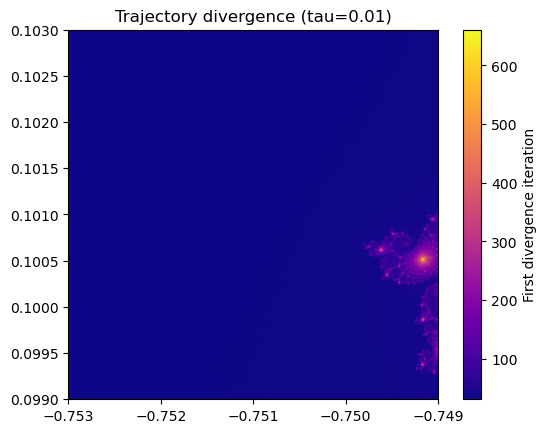

In [2]:
# Plot
tau=0.01
n=512
max_iter = 1000
diverge, active = mandelbrot_trajectory_divergence(N=n,MAX_ITER=max_iter,TAU=tau)
plt.imshow(diverge, cmap='plasma', origin='lower',
           extent=[-0.7530, -0.7490, 0.0990, 0.1030])
plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence (tau={tau})')
plt.show()

Note from Jimmy: Complex number has both real and imaginary parts. So for `complex128` each part gets 64 bits etc.

****Algorithm:****
1. **Build two coordinate arrays: `C32 = C.astype(np.complex64)` and `C64`**
2. **Iterate $z_{n+1} = z^n_2 + c$ simultaneously for both dtypes, step by step**
3. **Record the first iteration $k$ where $|z_{32}^{(k)} − z_{64}^{(k)} | > \tau $ (try $\tau = 0.01$)**
4. **Map these divergence iterations over the grid with `plt.imshow`**

****Observations to make:****

- **What fraction of pixels diverge before `max_iter`?**

In [3]:
pixels_total = diverge.size
pixels_diverged = np.sum(diverge < max_iter)

print(f"Out of {pixels_total:d} pixels, {pixels_diverged:d} pixels diverged")
print(f"A fraction of: {(pixels_diverged/pixels_total)*100:.2f}%")

Out of 262144 pixels, 262144 pixels diverged
A fraction of: 100.00%


- **Where do trajectories diverge *early*? Compare visually to the escape-count map.**

"escape-count map" is just the normal mandelbrot algorithm. 

*Note:* that I am using my numpy implementation to compare against.

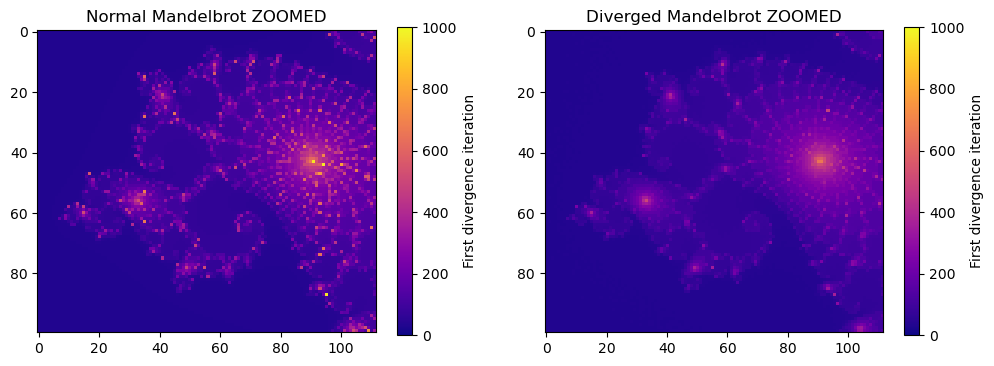

In [ ]:
from mandelbrot import compute_mandelbrot_numpy

tau=0.01
n=512
max_iter = 1000
x_min = -0.7530
x_max = -0.7490
y_min = 0.0990
y_max = 0.1030

normal_image = compute_mandelbrot_numpy(x_min, x_max, y_min, y_max, n, n, max_iter)
diverged_image, _ = mandelbrot_trajectory_divergence(x_min, x_max, y_min, y_max, n, max_iter, tau)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Iterations
im1 = axes[0].imshow(normal_image[150:250, 400:], cmap='plasma', vmin=0, vmax=max_iter)
axes[0].set_title("Normal Mandelbrot ZOOMED")
plt.colorbar(im1, label='First divergence iteration')

# Diverges
im2 = axes[1].imshow(diverged_image[150:250, 400:], cmap='plasma', vmin=0, vmax=max_iter)
axes[1].set_title("Diverged Mandelbrot ZOOMED")
plt.colorbar(im2, label='First divergence iteration')

plt.show()

Pixels diverge early in the purple and later in the yellow. From the images it appears that both diverges late in the complex contours of the mandelbrot shape, except that the diverged function on the left, reaches it quicker.

- **Does early divergence correlate with high escape iteration counts?**

Yes it does. By looking at the figures above, diverges does correlate to iteration counts.

****Done?** Record region, $\tau$ , and a brief observation in your performance notebook (MP3) → commit.**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 0cc8b727791394bda019c8f8bf4d7ea084edee76 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Apr 12 12:07:40 2026 +0000

    l08: milestone 1 done
```

### ****Milestone 2:** Mandelbrot Sensitivity Map**

****Goal:** compute a per-pixel condition number approximation for $f(c) = n_{escape}(c)$.**

From theory: $\kappa(f, c) =  |\frac{c f´(c)}{f(c)}|$. Substituting $f′(c) \approx \Delta n/\delta$ and $\delta = \varepsilon_{32} \cdot |c|$:

$$
\kappa(c) \approx \frac{|\Delta n|}{\varepsilon_{32} \cdot n(c)}, 
\space 
\Delta n = n(c + \delta) − n(c)
$$

****Region:** same as M1 (Seahorse Valley, `max_iter = 1000`)**

In [ ]:
# From slide 40

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
N, MAX_ITER = 512, 1000
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)
def escape_count(C, max_iter):
    z = np.zeros_like(C); cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)
    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k; esc[newly] = True
    return cnt
n_base      = escape_count(C,         MAX_ITER).astype(float)
n_perturb   = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)
cmap_k = plt.cm.hot.copy(); cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)
plt.imshow(kappa, cmap=cmap_k, origin='lower',
           extent=[-0.7530, -0.7490, 0.0990, 0.1030],
           norm=LogNorm(vmin=1, vmax=vmax))
plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title(r'Condition number approx $\kappa(c) = |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()

****Algorithm:****
1. **Compute $n(c)$ and $n(c + \delta)$; $\delta = \varepsilon_{32} \cdot |c|$**
2. **$\kappa(c) = |\Delta n| / (\varepsilon_{32} \cdot n(c))$; use `np.nan` where $n(c) = 0$**
3. **Plot with `cmap='hot'` and `LogNorm` ($\kappa$ spans many orders of magnitude; linear scale → black image). Use `vmin=1` ($\kappa < 1$ is well-conditioned). Set `cmap.set_bad('0.25')` so NaN pixels (grey) are not confused with high-$\kappa$ pixels (white).**

****Observations:****
- **Where is $\kappa$ largest? Does it match the boundary in M1?**
- **What is $\kappa$ for interior pixels (`n = max_iter`)?**

****Done?** Add a brief note comparing M1 and M2 maps to your performance notebook (MP3) → commit.**